In [1]:
import sctop as top
import pandas as pd
import numpy as np
import scanpy as sc
import scipy
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from collections import Counter
import plotly.io as pio
import anndata as ad
import h5py
import sys
import os
sys.path.append('/restricted/projectnb/crem-trainees/Kotton_Lab/Eitan/Vilker_Helper_Files/scTOP')
%load_ext autoreload
%autoreload 1
%aimport SimilarityHelper
%aimport TopObject
sys.path.append('/restricted/projectnb/crem-trainees/Kotton_Lab/Eitan/Transdifferentiation')
%aimport CriticalityHelper
pio.renderers.default = 'notebook'
os.chdir('/restricted/projectnb/crem-trainees/Kotton_Lab/Eitan/Vilker_Helper_Files/scTOP/KRT17_Reporter')

In [74]:
basisCollection = "/restricted/projectnb/crem-trainees/Kotton_Lab/Eitan/OutsidePaperObjects/Bases/BasisCollection.csv"
LungMAP = SimilarityHelper.loadBasis(file="./LungMAPANOVA.csv", basisCollection=basisCollection, basisName="LungMAPANOVA",
                                         basisKeep=["AT2", "AT1", "Basal", "Ciliated", "Goblet"]#, "Secretory"]
)
HaberMAP = SimilarityHelper.loadBasis(file="./HaberMAP500ANOVA02.csv", basisCollection=basisCollection, basisName="HaberMAP500ANOVA2",
                                         basisKeep=["AT2", "AT1", "Basal", "Ciliated", "Goblet", "Secretory", "KRT5-/KRT17+"]
)

Loaded HaberMAP500ANOVA2 basis!


In [ ]:
## Add dataset with prompts to guide you
summaryFile = "/restricted/projectnb/crem-trainees/Kotton_Lab/Eitan/Vilker_Helper_Files/scTOP/DatasetInformation.csv"
TopObject.dynamicAddDataset(summaryFile=summaryFile)
# celltype is subcluster_names

In [3]:
lauren = TopObject.TopObject("Lauren_06_24_25", skipProcess=False)

Setting AnnData object...
Setting AnnData...
Setting metadata and df...
Processing scTOP data...
Finished setup!


In [10]:
lauren.annotations.value_counts()

subcluster_names
iAT1                        3579
Proliferating (distal)      2258
iAT2                        2081
iBC 1                       1741
iBC 2                       1315
SOX high TGFB-treated       1137
Differentiating Airway      1035
Proliferating (proximal)     930
ABI2                         900
ABI1                         671
PNEC-like                    231
Non-lung contaminant          21
Name: count, dtype: int64

In [75]:
# lauren.project(lungMAP, "LungMAP")
lauren.project(HaberMAP, "HaberMAP")

Projecting onto basis...
Finished projecting! 1183 genes were in both the source and basis.


,AAACCCTGTTGCATGT-1,AAACGATGTAACGCTT-1,AAACGATGTAGTCAGA-1,AAACGATGTCATTAGC-1,AAACGATGTCCATCTC-1,AAACGATGTTCGTGGC-1,AAACGATGTTGAGCCC-1,AAACGATGTTTCGGTG-1,AAACTCCGTTAGTCCG-1,AAACTCCGTTCGCCAA-1,...,TGTGGTCAGATTACCG-1,TGTGGTCAGCAATCGC-1,TGTGGTCAGGATGGTG-1,TGTGGTCAGGATTAAG-1,TGTGTTGAGCGAATGG-1,TGTGTTGAGGATAGGT-1,TGTGTTGAGGATCTCA-1,TGTGTTGAGTAACCTG-1,TGTGTTGAGTGAGGAT-1,TGTGTTGAGTTAGTCG-1
AT1,0.037736,-0.013560,0.023984,0.000760,0.008145,0.007342,0.011685,0.009386,-0.008334,0.055064,...,-0.015845,0.017476,0.017032,-0.007423,-0.035728,-0.014719,-0.008523,0.015191,0.001428,0.016296
AT2,0.078461,0.087856,0.096691,0.069766,0.046951,0.099534,0.082879,0.091066,0.100103,0.082053,...,0.064478,0.048978,0.066730,0.068703,0.063691,0.050452,0.076473,0.059708,0.070159,0.056547
Basal,0.067464,0.090428,0.067371,0.057150,0.089741,0.078212,0.042553,0.050572,0.097649,0.062827,...,0.059529,0.206658,0.229853,0.198985,0.195086,0.170947,0.036967,0.184155,0.090968,0.177484
Ciliated,-0.113789,-0.105120,-0.135550,-0.125305,-0.058454,-0.106715,-0.108315,-0.100006,-0.105344,-0.141017,...,-0.133062,-0.126894,-0.137140,-0.135094,-0.116943,-0.123469,-0.135419,-0.119095,-0.158063,-0.138974
Goblet,-0.068198,-0.056605,-0.065614,-0.039963,-0.055248,-0.070700,-0.051893,-0.055931,-0.037675,-0.048894,...,-0.021656,-0.028818,-0.011297,0.005464,-0.037884,-0.042417,0.018795,-0.027459,0.013592,-0.026506
Secretory,0.068196,0.052174,0.071812,0.041428,0.028932,0.053498,0.062247,0.051162,0.043782,0.060306,...,0.134540,-0.059569,-0.070823,-0.076999,-0.014877,0.043559,0.123099,-0.063537,0.098918,-0.015161
KRT5-/KRT17+,0.037291,0.039080,0.052069,0.101762,0.019667,0.037688,0.066570,0.056927,0.011422,0.045410,...,0.021013,0.051158,0.048567,0.070362,0.054315,0.025547,0.026249,0.080193,0.001878,0.050666


Similarity map built!


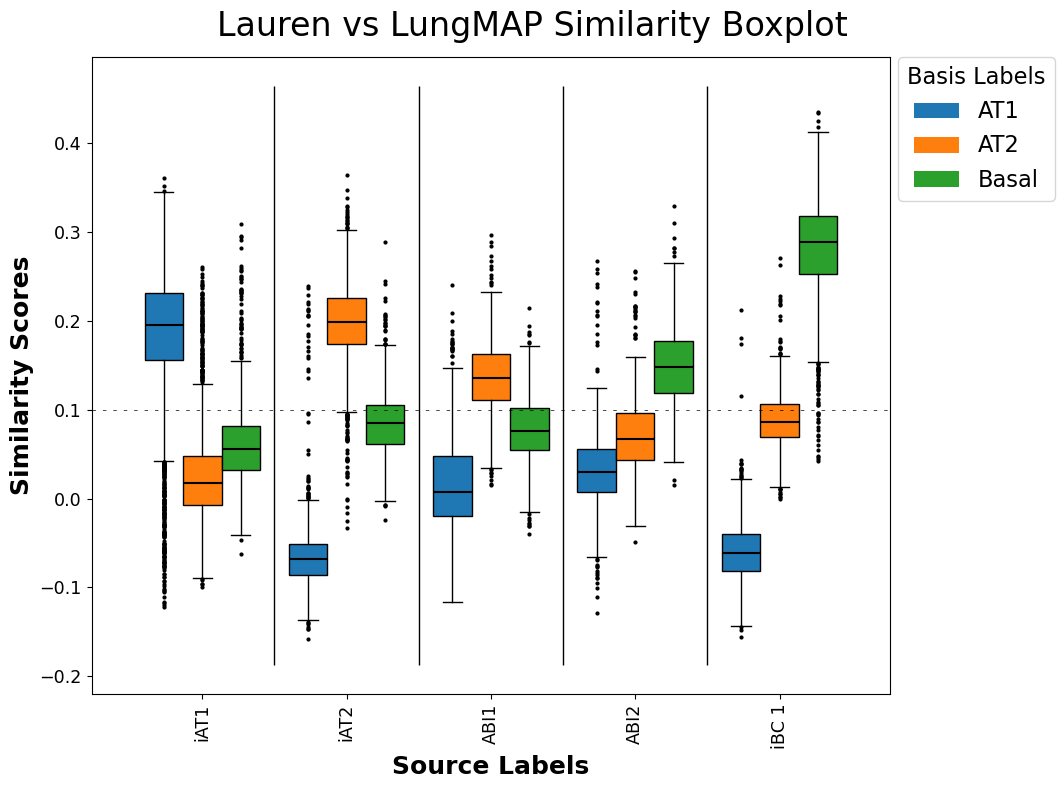

In [68]:
basisKeep = ["AT1", "AT2", "Basal"]#, "Ciliated", "Goblet"]
testKeep =  ["iAT1", "iAT2", "ABI1", "ABI2", "iBC 1"]

# First step: Create map of basis labels to the projections of cells with each source label onto said basis labels
laurenSimilarityMap = SimilarityHelper.getMatchingProjections(lauren, "LungMAP", basisKeep=basisKeep, sourceKeep=testKeep)

# Second step: Set basic parameters like plot size and title and generate boxplot
SimilarityHelper.similarityBoxplot(laurenSimilarityMap, basisKeep=basisKeep, sourceKeep=testKeep, title="Lauren vs LungMAP Similarity Boxplot", 
                                   # outFile="../results/Lauren vs LungMAP 500 Boxplot.png"
)

Similarity map built!


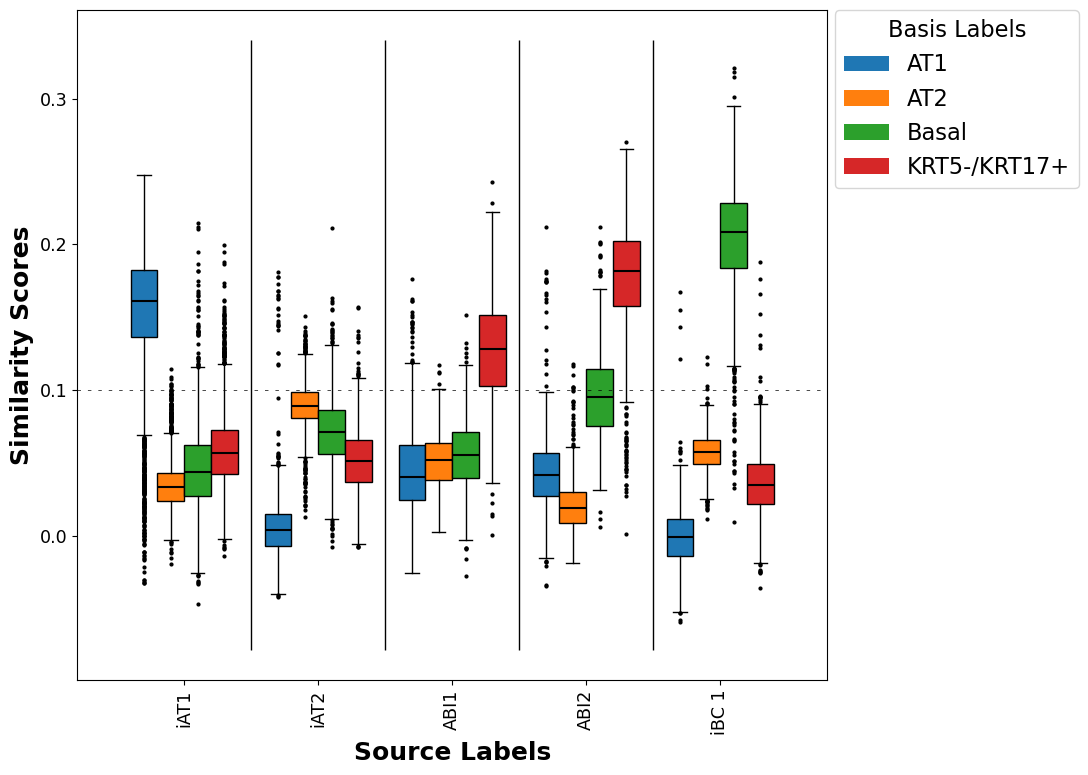

In [77]:
basisKeep = ["AT1", "AT2", "Basal", "KRT5-/KRT17+"]#, "Ciliated", "Secretory"]
testKeep =  ["iAT1", "iAT2", "ABI1", "ABI2", "iBC 1"]

# First step: Create map of basis labels to the projections of cells with each source label onto said basis labels
laurenSimilarityMap = SimilarityHelper.getMatchingProjections(lauren, "HaberMAP", basisKeep=basisKeep, sourceKeep=testKeep)

# Second step: Set basic parameters like plot size and title and generate boxplot
SimilarityHelper.similarityBoxplot(laurenSimilarityMap, basisKeep=basisKeep, sourceKeep=testKeep, #title="Lauren vs HaberMAP Similarity Boxplot", 
                                   # outFile="../results/Lauren vs HaberMAP Boxplot.pdf"
)

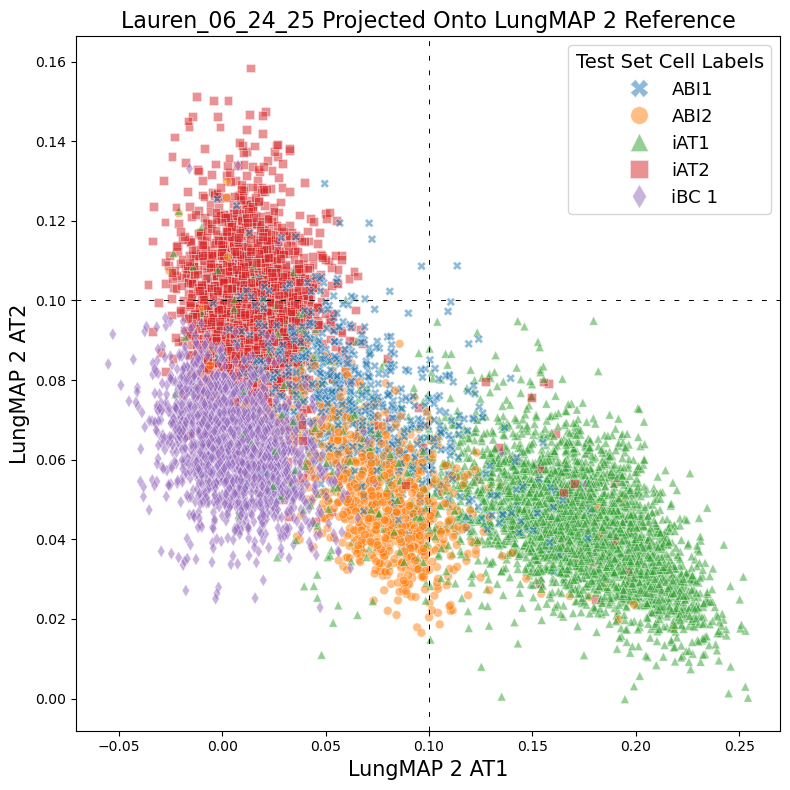

In [32]:
# Now do a scatter plot against two axes
keepList = ["iAT1", "iAT2", "ABI1", "ABI2", "iBC 1"]
axis1 = "AT1"
axis2 = "AT2"
includeCriteria = lauren.annotations.isin(keepList)
ax = SimilarityHelper.plotTwo(lauren, "LungMAP", axis1, axis2, 
    includeCriteria=includeCriteria, supervisedContour=False,
    # outFile="../results/Lauren vs LungMAP AT1 vs AT2.png"
)

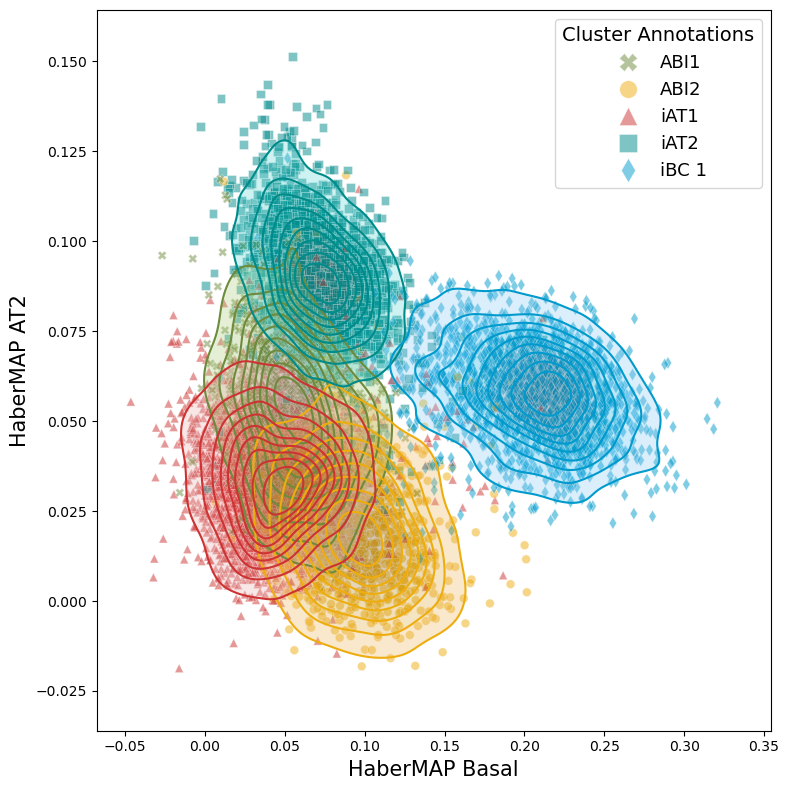

In [107]:
# Now do a scatter plot against two axes
keepList = ["iAT1", "iAT2", "ABI1", "ABI2", "iBC 1"]
# axis1 = "KRT5-/KRT17+"
axis1 = "Basal"
axis2 = "AT2"
includeCriteria = lauren.annotations.isin(keepList)
ax = SimilarityHelper.plotTwo(lauren, "HaberMAP", axis1, axis2, includeCriteria=includeCriteria,
    supervisedContour=True, title=None, legendTitle="Cluster Annotations", plotThreshold=False, source="lauren",
    # outFile="../results/Lauren vs HaberMAP Basal vs AT2.pdf"
)

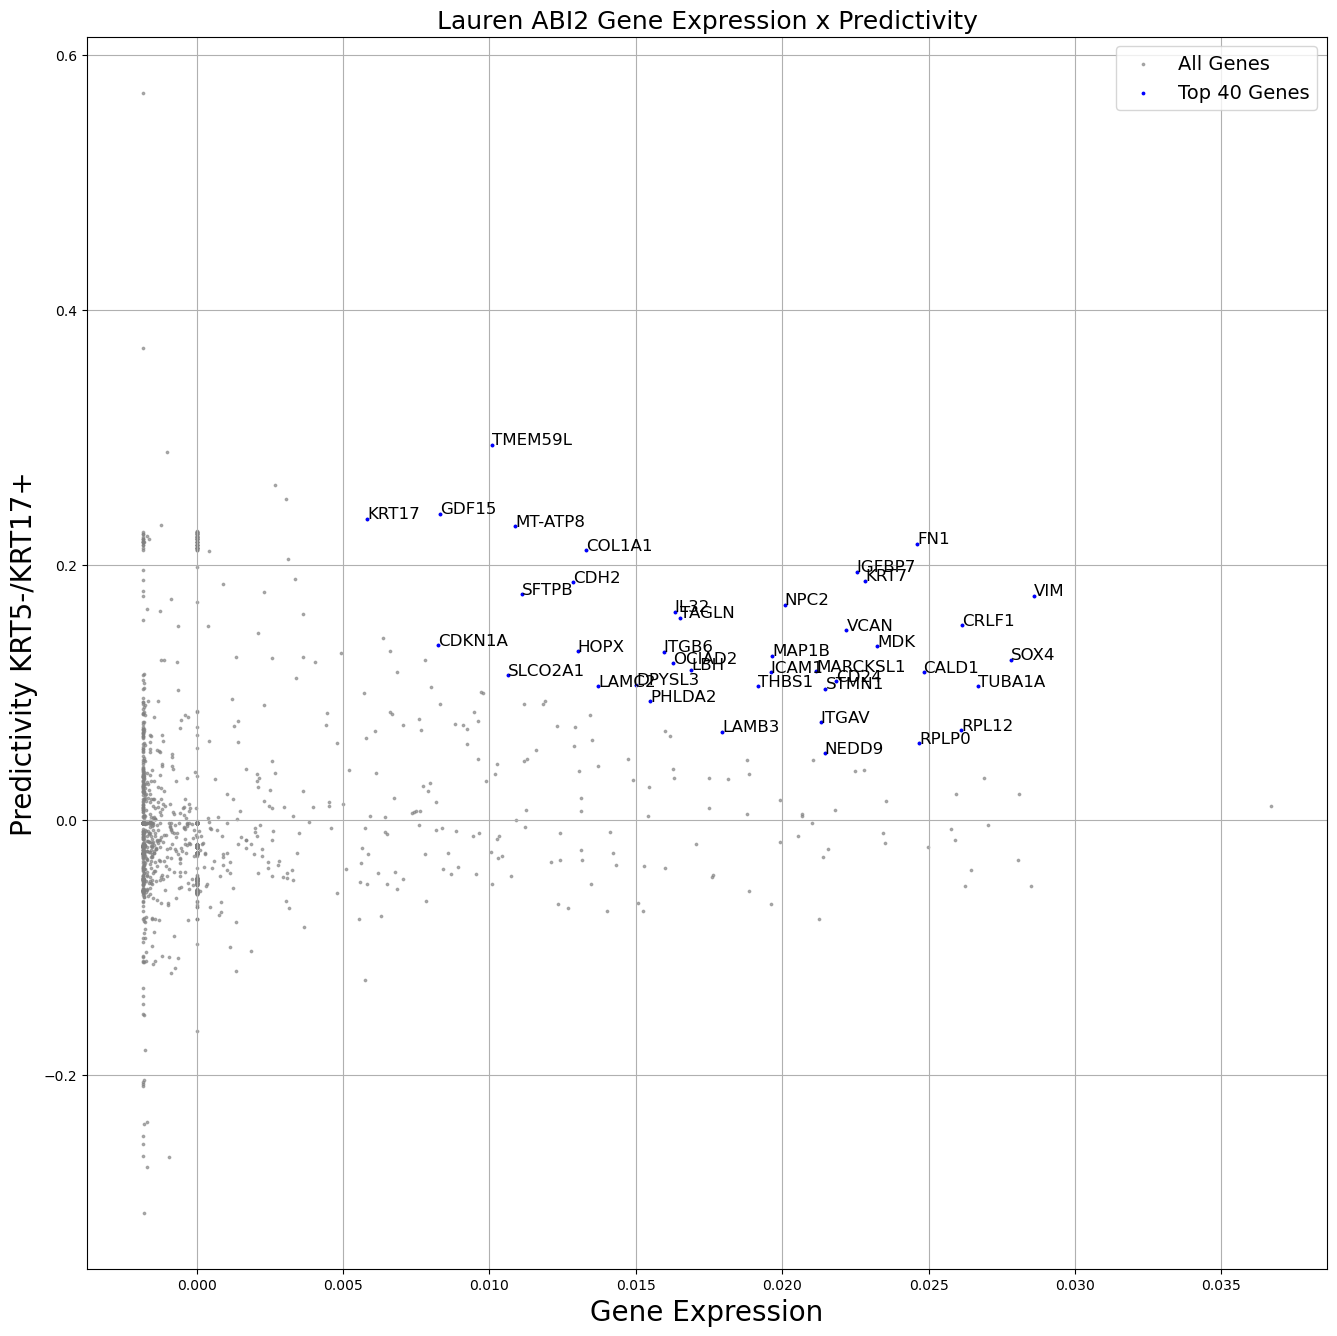

In [109]:
SimilarityHelper.plotPredictivity(lauren, "KRT5-/KRT17+", basis=HaberMAP, showHigh=40, sourceLabel="ABI2",
          figX=16, figY=16, 
          title="Lauren ABI2 Gene Expression x Predictivity", 
          # outFile="../results/Lauren vs HaberMAP ABI2 vs Habermann ABI Predictivity 40.pdf"
)